In [55]:
include("parisiSolvers.jl")
using Plots
using Optim
using ADTypes: AutoForwardDiff
import ForwardDiff

In [56]:
K = 10
tgrid = collect(range(0.0, 1.0, length=K+1));

theta0 = log.(fill(0.05, K))  
g0 = theta_to_g(theta0);



In [57]:
lower = zeros(K)  
upper = ones(K)
# upper = fill(Inf, K)
p = 4
objective_g = make_objective_g(tgrid; L=8.0, Nx=1001, Q=40, p=p)

# # @time res = optimize(objective, theta0, BFGS()) #14s, 16GB
# # @time res = optimize(objective, theta0, LBFGS(; m=10)) #29s, 33GB
# @time res = optimize(objective, theta0, LBFGS(); autodiff=AutoForwardDiff()) #6s, 17GB

# # @time res = optimize(objective_g, g0, LBFGS(); autodiff=AutoForwardDiff()) #

λ = 1000
loss_fn(g) = objective_g(g) + λ * sum(max(0, g[i]-g[i+1])^2 for i in 1:K-1)

@time res = Optim.optimize(loss_fn, lower, upper, g0, Fminbox(LBFGS()); autodiff=AutoForwardDiff()) #



 35.122990 seconds (1.82 M allocations: 82.135 GiB, 45.44% gc time, 2.75% compilation time: 12% of which was recompilation)


 * Status: success

 * Candidate solution
    Final objective value:     1.170235e+00

 * Found with
    Algorithm:     Fminbox with L-BFGS

 * Convergence measures
    |x - x'|               = 2.51e-11 ≰ 0.0e+00
    |x - x'|/|x'|          = 2.51e-11 ≰ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 0.0e+00
    |g(x)|                 = 9.05e-08 ≰ 1.0e-08

 * Work counters
    Seconds run:   35  (vs limit Inf)
    Iterations:    6
    f(x) calls:    824
    ∇f(x) calls:   824
    ∇f(x)ᵀv calls: 0


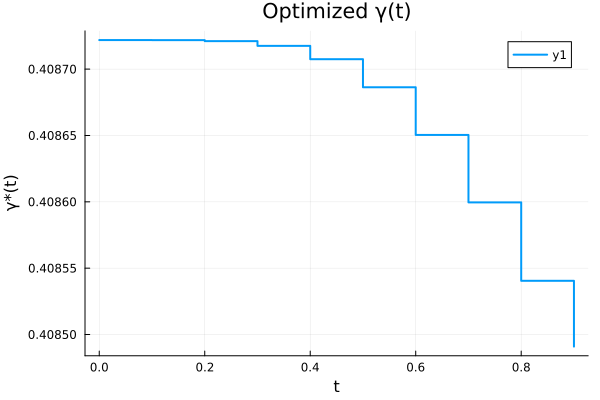

In [54]:
g_star = Optim.minimizer(res)

plot(
    tgrid[1:end-1],
    g_star,
    seriestype=:steppost,
    xlabel="t",
    ylabel="γ*(t)",
    linewidth=2,
    # label="p = $p",
    title = "Optimized γ(t)",
)

### True Constrained Optimization

In [40]:
using NLopt

K = 10
tgrid = collect(range(0.0, 1.0, length=K+1))                                                                                                                               
g0 = collect(range(0.1, 0.9, length=K))  # monotone initial guess                                                                                                        

10-element Vector{Float64}:
 0.1
 0.18888888888888888
 0.2777777777777778
 0.36666666666666664
 0.45555555555555555
 0.5444444444444444
 0.6333333333333333
 0.7222222222222222
 0.8111111111111111
 0.9

In [ ]:
opt = Opt(:LD_MMA, K)
opt.lower_bounds = zeros(K)                                                                                                                                                
opt.upper_bounds = ones(K)                                                                                                                                               
opt.ftol_rel = 1e-8                                                                                                                                                        

opt.min_objective = (g, grad) -> begin                                                                                                                                     
    val = parisi_functional(tgrid, g)                                                                                                                                 
    if length(grad) > 0
        grad .= ForwardDiff.gradient(g_ -> parisi_functional(tgrid, g_), g)
    end                                                                                                                                                                    
    return val
end                                                                                                                                                                        
                                                                                                                                                                        
for i in 1:K-1
    inequality_constraint!(opt, (g, _) -> g[i] - g[i+1], 1e-8)
end                                                                                                                                                                        


In [ ]:
minval, g_star, ret = NLopt.optimize(opt, g0)                                                                                                                                    
println("Return code: ", ret)                                                                                                                                            
println("g* = ", g_star)
